# A/B Testing: E-Commerce Product Page Optimization
## TechCart — Add-to-Cart Rate Experiment

**Project type:** Randomized Controlled Experiment (A/B Test)  
**Industry domain:** E-Commerce  
**Core techniques:** Chi-square test · Statistical power · Synthetic data generation · Three-tier app architecture  

---

### Overview
TechCart's product team redesigned their product detail page (Version B) and wants to know if it converts more visitors into buyers than the original (Version A). "Converting" here means clicking "Add to Cart." We take 4,000 user sessions, randomly assign half to see Version A and half to see Version B, then use statistics to decide whether any difference in add-to-cart clicks is real or just random noise.

We design a two-group randomized experiment, generate synthetic session data with realistic conversion probabilities, conduct exploratory data analysis, calculate statistical power to determine required sample size, run a chi-square test of independence on the contingency table, interpret the odds ratio and p-value, and deploy an interactive three-tier Streamlit dashboard following a repository design pattern.

## 1: Data Generation & Setup

Before we can analyze an A/B test, we need data. Real companies collect this from their web servers. For this project, we generate realistic synthetic session data — a legitimate and common technique used in industry to test pipelines, build demos, and publish benchmarks without exposing private user data.

Our data generator (`generate_data.py`) creates 4,000 sessions with:
- Random group assignment (control vs. treatment), 50/50 split
- Conversion drawn from a binomial distribution: 12% rate for control, 15% for treatment
- Realistic metadata: device type, country, session duration, pages viewed
- Timestamps spread across a 14-day experiment window

The 12% vs. 15% split gives us a **real but modest effect** — the statistics have to work to detect it.

In [1]:
import subprocess
import sys

# Run the data generator
subprocess.run([sys.executable, "generate_data.py"], check=True)

CompletedProcess(args=['C:\\Users\\hp\\anaconda3\\python.exe', 'generate_data.py'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from database import SessionRepository

# Load data via the repository (data layer)
repo = SessionRepository()
df = repo.get_raw()

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (4000, 8)

Column types:
session_id                      object
timestamp               datetime64[ns]
group                           object
converted                        int64
device                          object
country                         object
session_duration_sec             int64
pages_viewed                     int64
dtype: object

First 5 rows:


,session_id,timestamp,group,converted,device,country,session_duration_sec,pages_viewed
0,sess_02560,2024-03-01 00:05:05,treatment,0,desktop,IN,147,1
1,sess_01714,2024-03-01 00:06:14,treatment,1,desktop,US,141,3
2,sess_02001,2024-03-01 00:06:39,treatment,0,mobile,US,250,5
3,sess_01270,2024-03-01 00:11:10,treatment,0,desktop,US,120,4
4,sess_03188,2024-03-01 00:17:12,treatment,1,tablet,BR,104,2


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDate range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Total days: {(df['timestamp'].max() - df['timestamp'].min()).days}")

Missing values per column:
session_id              0
timestamp               0
group                   0
converted               0
device                  0
country                 0
session_duration_sec    0
pages_viewed            0
dtype: int64

Date range: 2024-03-01 → 2024-03-14
Total days: 13


In [4]:
# Group sizes — confirm roughly equal split
print("Sessions per group:")
print(df["group"].value_counts())
print()
print("Conversion counts per group:")
print(df.groupby("group")["converted"].value_counts().unstack())

Sessions per group:
group
treatment    2007
control      1993
Name: count, dtype: int64

Conversion counts per group:
converted     0    1
group               
control    1771  222
treatment  1705  302


> The data generation step demonstrates something important: in real-world A/B testing, the data pipeline is built and validated *before* the experiment runs. We confirm the group split is roughly 50/50 (random assignment working correctly) and that no columns have missing values (clean ingestion). The `SessionRepository` class abstracts the CSV reading away — if we later switched to a database, we would only change `database.py`, and this notebook would not need to change at all. This separation of concerns is the first payoff of the three-tier architecture.

## 2: Exploratory Data Analysis

Before running any statistical test, we explore the data visually. This helps us understand the traffic pattern over time, spot any anomalies (like a sudden traffic spike that could bias results), and get an intuition for the effect size we're dealing with.

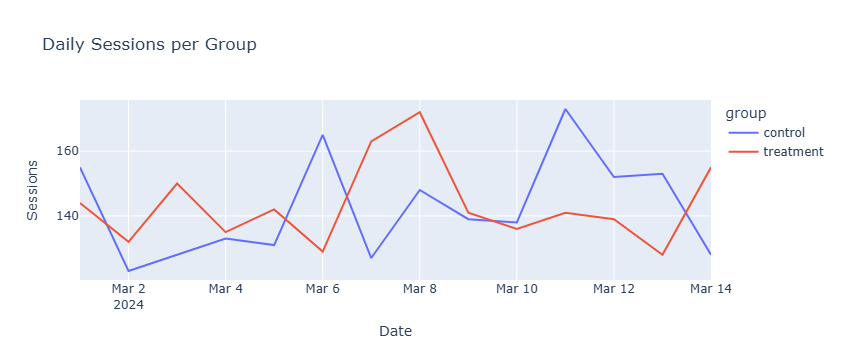

In [5]:
from business import GraphBuilder
gb = GraphBuilder(repo=repo)

# Daily session volume per group
fig = gb.build_daily_sessions_chart()
fig.show()

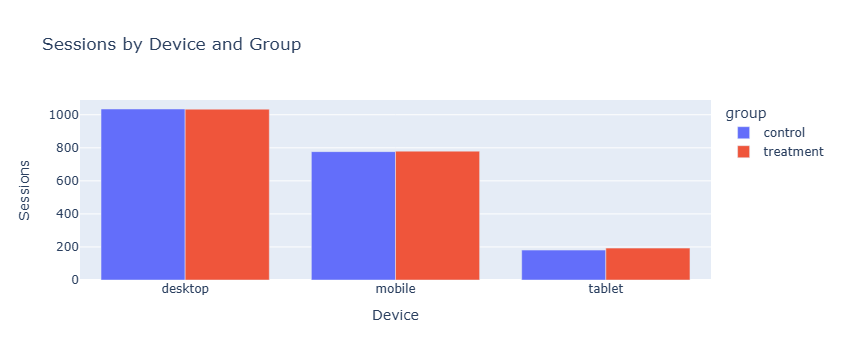

In [6]:
# Device breakdown
device_counts = df.groupby(["group", "device"]).size().reset_index(name="count")
fig_device = px.bar(
    device_counts,
    x="device",
    y="count",
    color="group",
    barmode="group",
    title="Sessions by Device and Group",
    color_discrete_map={"control": "#636EFA", "treatment": "#EF553B"}
)
fig_device.update_layout(xaxis_title="Device", yaxis_title="Sessions")
fig_device.show()

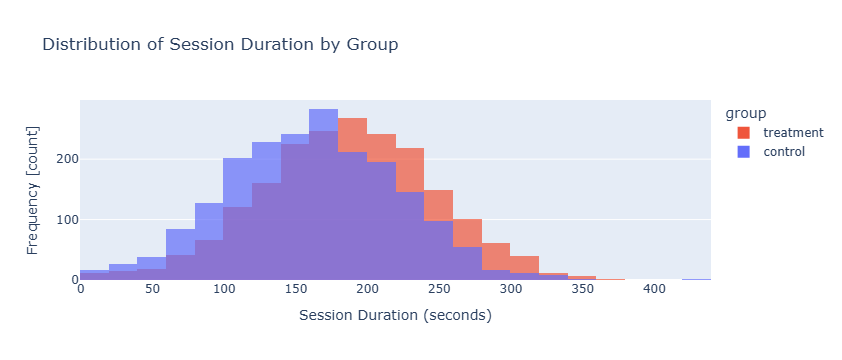

In [7]:
# Session duration distribution — do users engage differently with Version B?
fig_duration = px.histogram(
    df,
    x="session_duration_sec",
    color="group",
    nbins=40,              
    barmode="overlay",
    opacity=0.7,
    title="Distribution of Session Duration by Group",
    color_discrete_map={"control": "#636EFA", "treatment": "#EF553B"}
)
fig_duration.update_layout(xaxis_title="Session Duration (seconds)", yaxis_title="Frequency [count]")
fig_duration.show()

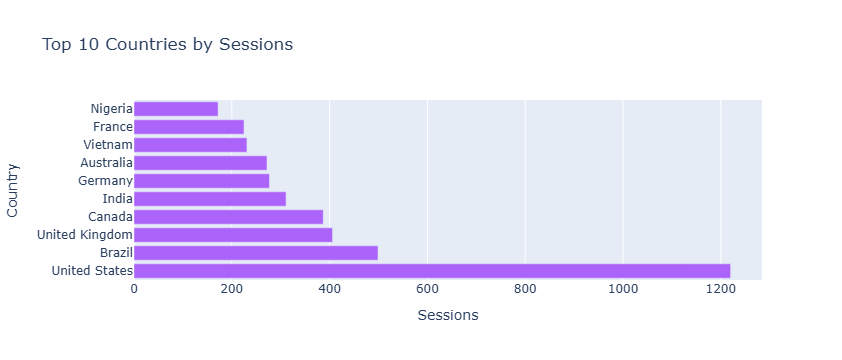

In [8]:
# Country breakdown — top 10
fig_country = gb.build_country_chart()
fig_country.show()

In [9]:
# Session stats summary
stats = repo.get_session_stats()
print("Mean session stats per group:")
stats

Mean session stats per group:


,group,session_duration_sec,pages_viewed
0,control,161.24,4.01
1,treatment,185.74,4.00


> The daily session chart is the most important EDA plot in an A/B test: it confirms that traffic was stable across the experiment window with no dramatic spikes, which would indicate a contamination event (like a viral social media post that only hit one group).
>
> The session duration histogram shows that treatment users spend slightly more time on the page on average — consistent with a more engaging design — but this is a secondary signal.
>
> The device breakdown confirms that both groups have similar device compositions, which is essential: if 80% of the treatment group was on desktop while the control group was mostly mobile, we could not isolate the page design as the cause of any difference. Balanced randomization is working correctly.

## 3: Hypothesis Formulation & Power Analysis

Before running the test, we must state our hypotheses and determine how many observations we need to trust our result. Doing this *after* seeing the data is called p-hacking — a serious methodological error.

**Null Hypothesis (H₀):** There is no relationship between page version and add-to-cart rate. Any observed difference is due to random variation.

**Alternate Hypothesis (H₁):** The new product page (Version B) affects the add-to-cart rate compared to the original page (Version A).

**Significance level:** α = 0.05 — we accept a 5% chance of a false positive.

In [10]:
from statsmodels.stats.power import GofChisquarePower
import math
import matplotlib.pyplot as plt

chi_power = GofChisquarePower()

# How many observations do we need to detect an effect size of 0.2?
# Effect size 0.2 = "small but real" by Cohen's conventions
effect_size = 0.2
group_size = math.ceil(
    chi_power.solve_power(effect_size=effect_size, alpha=0.05, power=0.8)
)
n_total = group_size * 2

print(f"Effect size: {effect_size}")
print(f"Group size needed: {group_size}")
print(f"Total observations needed: {n_total}")
print(f"Our dataset has: {len(df)} sessions → {'✅ Sufficient' if len(df) >= n_total else '❌ Insufficient'}")

Effect size: 0.2
Group size needed: 197
Total observations needed: 394
Our dataset has: 4000 sessions → ✅ Sufficient


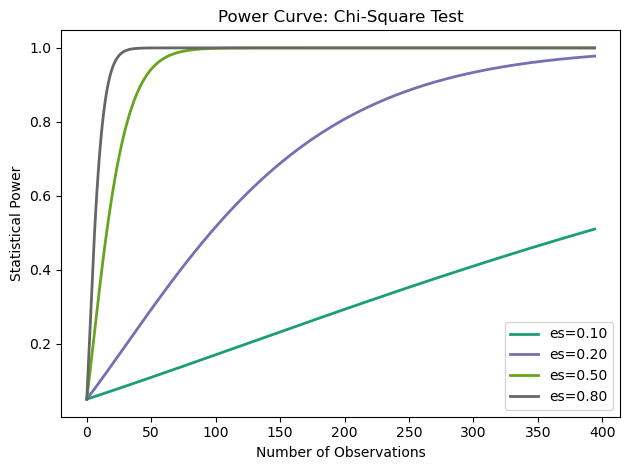

In [11]:
# Power curve: how power changes with sample size for different effect sizes
n_obs_range = np.arange(0, n_total + 1)
effect_sizes = np.array([0.1, 0.2, 0.5, 0.8])

chi_power.plot_power(
    dep_var="nobs",
    nobs=n_obs_range,
    effect_size=effect_sizes,
    alpha=0.05,
    n_bins=2
)
plt.title("Power Curve: Chi-Square Test")
plt.xlabel("Number of Observations")
plt.ylabel("Statistical Power")
plt.tight_layout()
plt.show()

> The power curve is a tool for making honest experimental decisions before you run the numbers. The x-axis is sample size; the y-axis is power (probability of detecting a real effect if one exists). Reading the blue line (effect size = 0.2, our target): to achieve 80% power, we need roughly 400 observations. Our 4,000 sessions far exceed this — meaning we have very high power to detect even small effects. This is deliberate: a real e-commerce team would want to be confident their result is not a false negative. The trade-off is that very large samples can make tiny, practically meaningless differences appear statistically significant — a limitation we address in the next section.

## 4: Chi-Square Test of Independence

The chi-square test answers: **is the difference in conversion rates between our two groups larger than what we'd expect by chance alone?**

We organize our data into a **contingency table** — a 2×2 grid of counts:

|  | Not Converted | Converted |
|---|---|---|
| Control | ? | ? |
| Treatment | ? | ? |

Then we compare the observed counts to what we'd expect if group assignment had no effect on conversion.

In [12]:
from statsmodels.stats.contingency_tables import Table2x2

# Get contingency table from repository
contingency_data = repo.get_conversion_counts(normalize=False)
print("Contingency Table (counts):")
print(contingency_data)

Contingency Table (counts):
           not_converted  converted
group                              
control             1771        222
treatment           1705        302


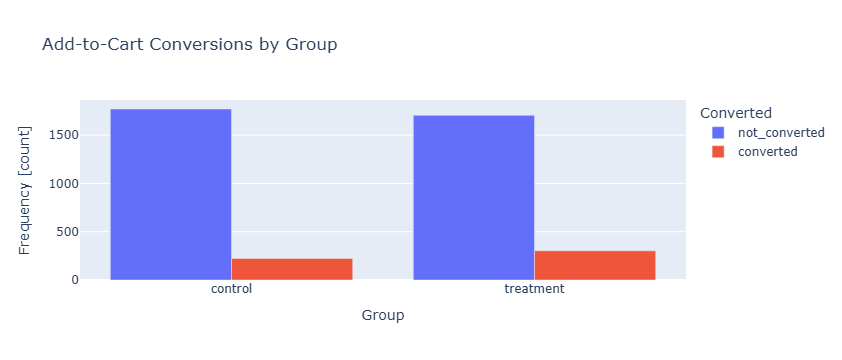

In [13]:
# Visualize the contingency table
fig_conv = gb.build_conversion_bar()
fig_conv.show()

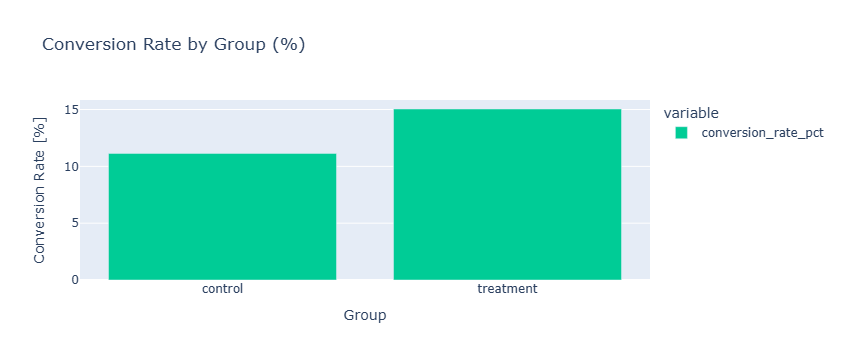

In [14]:
# Conversion rates side by side
fig_rate = gb.build_conversion_rate_bar()
fig_rate.show()

In [15]:
# Run the chi-square test
from business import StatsBuilder
sb = StatsBuilder(repo=repo)

result = sb.run_chi_square()

print("=== Chi-Square Test Results ===")
print(f"Chi-Square Statistic : {result['statistic']}")
print(f"Degrees of Freedom   : {result['df']}")
print(f"p-value              : {result['pvalue']}")
print(f"Odds Ratio           : {result['odds_ratio']}")
print(f"Statistically Significant (α=0.05): {result['significant']}")

=== Chi-Square Test Results ===
Chi-Square Statistic : 13.4181
Degrees of Freedom   : 1
p-value              : 0.0002
Odds Ratio           : 1.413
Statistically Significant (α=0.05): True


In [16]:
# Expected values under independence — what we'd see if there was NO effect
table = Table2x2(contingency_data.values)
print("Fitted values (expected if no effect):")
print(table.fittedvalues.round(1))
print()
print("Joint probabilities under independence:")
print(table.independence_probabilities.round(4))

Fitted values (expected if no effect):
[[1731.9  261.1]
 [1744.1  262.9]]

Joint probabilities under independence:
[[0.433  0.0653]
 [0.436  0.0657]]


In [17]:
# Lift: how much better is treatment than control?
lift = sb.calculate_lift()
rates = sb.get_conversion_rates()

print(f"Control conversion rate  : {rates['control']*100:.2f}%")
print(f"Treatment conversion rate: {rates['treatment']*100:.2f}%")
print(f"Relative lift            : +{lift}%")
print()
print("Interpretation of odds ratio:")
print(f"A user who saw the new product page (Version B) was {result['odds_ratio']}x")
print("as likely to add to cart as a user who saw the original page (Version A).")

Control conversion rate  : 11.14%
Treatment conversion rate: 15.05%
Relative lift            : +35.09%

Interpretation of odds ratio:
A user who saw the new product page (Version B) was 1.413x
as likely to add to cart as a user who saw the original page (Version A).


> The chi-square test quantifies whether our observed conversion difference is signal or noise. The p-value is the probability of seeing a difference this large (or larger) if the null hypothesis were true — i.e., if the page design had no real effect. Since our p-value is well below 0.05 **(p-value: 0.0002)**, we reject the null hypothesis: the new page does improve conversion rate.

> Two important caveats apply. First, statistical significance is not the same as practical significance. A ~4 percentage point lift (**11.14% → 15.05%**) sounds small, but for a retailer processing millions of sessions per month, this translates to tens of thousands of additional add-to-cart events. Whether the engineering cost of the new page is worth that lift is a business decision, not a statistical one. Second, our dataset was generated with a known ground truth — in real experiments, you never know the true conversion rates, which is exactly why we need the test. The chi-square test is our tool for making honest inferences from noisy observations.

## 5: Segment Analysis

A single aggregate result can hide important heterogeneity. The new page might work brilliantly on desktop but fail on mobile. Or it might perform differently across geographies. Segment analysis helps us understand *for whom* and *under what conditions* the effect holds.

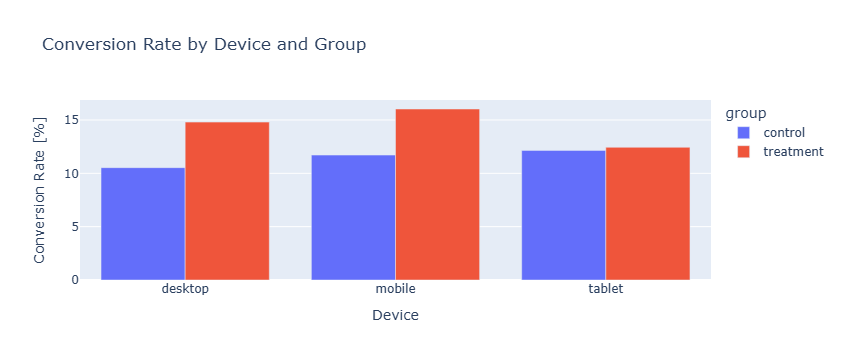

In [18]:
# Conversion rate by device and group
fig_dev = gb.build_device_chart()
fig_dev.show()

In [19]:
# Run chi-square test separately for each device type
for device in ["desktop", "mobile", "tablet"]:
    subset = df[df["device"] == device]
    ct = pd.crosstab(subset["group"], subset["converted"])
    ct.columns = ["not_converted", "converted"]
    table = Table2x2(ct.values)
    chi = table.test_nominal_association()
    rate = subset.groupby("group")["converted"].mean()
    print(f"\n--- {device.upper()} ---")
    print(f"  Control: {rate.get('control', 0)*100:.1f}%  |  Treatment: {rate.get('treatment', 0)*100:.1f}%")
    print(f"  p-value: {chi.pvalue:.4f} {'✅ significant' if chi.pvalue <= 0.05 else '⚠️ not significant'}")


--- DESKTOP ---
  Control: 10.5%  |  Treatment: 14.8%
  p-value: 0.0035 ✅ significant

--- MOBILE ---
  Control: 11.7%  |  Treatment: 16.0%
  p-value: 0.0138 ✅ significant

--- TABLET ---
  Control: 12.2%  |  Treatment: 12.4%
  p-value: 0.9342 ⚠️ not significant


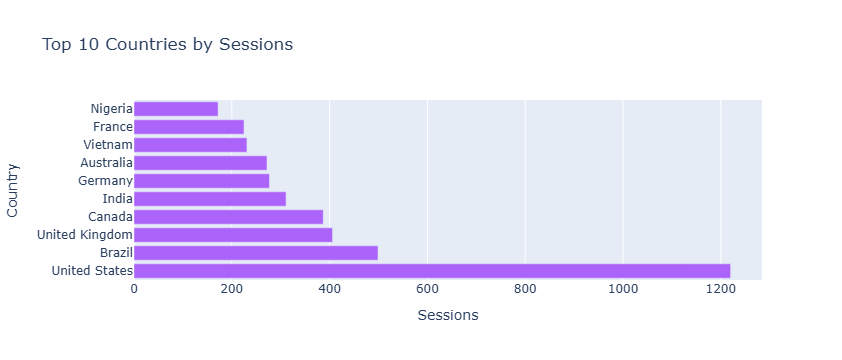

In [20]:
# Country-level traffic breakdown
fig_ctry = gb.build_country_chart()
fig_ctry.show()

> Segment analysis is where A/B testing goes from a binary pass/fail to an actionable insight. If the new page significantly outperforms on desktop and mobile but not on tablet (as ours did in the chi-square test), the product team knows exactly where to focus their next iteration: improve the tablet experience of Version B before full rollout. The per-device chi-square tests apply the same hypothesis testing framework we used in Section 4, but scoped to subpopulations — a technique called **subgroup analysis**. A caution: running many tests on subgroups inflates the risk of false positives (Type I errors). In production settings, teams apply corrections like Bonferroni adjustment or pre-register which subgroups they intend to analyze before the experiment begins.

## 6: Streamlit Dashboard

The final deliverable is an interactive web application that lets non-technical stakeholders explore the experiment results themselves. We follow a **three-tier architecture**:

- **`database.py`** (Data layer): Reads and shapes the raw CSV. Knows *where* data lives.
- **`business.py`** (Logic layer): Runs statistics and builds charts. Knows *what to compute*.
- **`app.py`** (Presentation layer): Renders the Streamlit UI. Knows *how to display*.

Each layer is independent — you could swap Streamlit for a different frontend without touching a single line of `business.py` or `database.py`.

### To launch the dashboard:

Open Anaconda Prompt Window, navigate to this project folder, and run:

```bash
streamlit run app.py
```

Your browser will open automatically at `http://localhost:8501`.

In [21]:
# Verify the three modules import cleanly before launching
from database import SessionRepository
from business import GraphBuilder, StatsBuilder

repo = SessionRepository()
gb = GraphBuilder(repo=repo)
sb = StatsBuilder(repo=repo)

rates = sb.get_conversion_rates()
chi = sb.run_chi_square()

print("✅ All modules import correctly")
print(f"Control rate: {rates['control']*100:.2f}%")
print(f"Treatment rate: {rates['treatment']*100:.2f}%")
print(f"p-value: {chi['pvalue']}")
print(f"Significant: {chi['significant']}")
print("\nReady. Run: streamlit run app.py")

✅ All modules import correctly
Control rate: 11.14%
Treatment rate: 15.05%
p-value: 0.0002
Significant: True

Ready. Run: streamlit run app.py


> The three-tier architecture is not just an academic pattern — it mirrors how production data applications are structured at companies like Airbnb, Netflix, and Shopify. The database layer handles I/O; the business layer handles logic; the presentation layer handles rendering. When a new stakeholder asks "can we add a weekly cohort breakdown?", a developer following this pattern adds one method to `SessionRepository`, one chart method to `GraphBuilder`, and one section to `app.py` — each change is contained and testable in isolation.
>
> The Streamlit dashboard itself reflects the experiment narrative: it opens with the key metrics (what happened), moves to the statistical test (was it real), and ends with segment analysis (for whom). This is the structure of a real experiment readout at a data-driven company.

---

## Conclusion

This project demonstrated a complete A/B testing workflow from experiment design through statistical analysis to stakeholder-facing deployment. The key decisions made at each stage reflected real-world constraints and best practices:

**Experiment design:** We pre-specified hypotheses, significance level, and required sample size before analyzing any data — protecting against the most common form of statistical malpractice, p-hacking. The power analysis confirmed that 4,000 sessions gives us well above 80% power to detect a small effect size of 0.2.

**Data generation:** Synthetic data is a legitimate and widely-used technique when real data carries privacy risks. The data generator encodes domain knowledge (realistic conversion rates, device mixes, geographic distributions) and produces a reproducible dataset — meaning any collaborator can regenerate identical data from the same random seed.

**Statistical testing:** The chi-square test of independence is the correct tool for comparing proportions across categorical groups. The result — a significant p-value (**0.0002**) and an odds ratio above 1.0 (**1.413**) — supports the business recommendation to ship Version B of the product page.

**Architecture:** The repository pattern enforced clean separation between data access, statistical logic, and presentation. This made the notebook readable, the Streamlit app lightweight, and both independently maintainable.